# Portfolio Allocation — Final Project
**Côme Genet, Paul Beaumont, Antoine Mazet**

---

## Objective

This notebook investigates the out-of-sample performance of various portfolio strategies on a large cross-section of US equities (Wiki Prices dataset), with a focus on two complementary questions:

1. **Does covariance matrix filtering improve portfolio performance?**  
   We compare raw sample covariance (MLE), Ledoit–Wolf linear shrinkage, RMT eigenvalue clipping, and EWMA covariance, all combined with Global Minimum Variance (GMV) optimization.

2. **Does Robust Optimization add value on top of filtered covariance?**  
   We layer a Scherer-type robust mean–variance objective over each filtered covariance and measure the incremental contribution net of transaction costs.

3. **Can a neural network replace hand-crafted covariance cleaning?**  
   We implement a `GMVNetwork` that learns to clean eigenvalues end-to-end via a biLSTM module, and compare it to the analytical benchmarks above.

Throughout, we enforce:
- **No look-ahead bias**: all estimates use strictly past data.
- **Realistic transaction costs**: 5 bps proportional cost at each rebalance.
- **Walk-forward backtesting**: rolling estimation windows with periodic rebalancing.

---

## Notebook structure

| Section | Content |
|---------|---------|
| 0 | Imports & global parameters |
| 1 | Data loading & preprocessing |
| 2 | Eigenvalue analysis (Marchenko–Pastur) |
| 3 | Covariance estimators |
| 4 | GMV walk-forward backtest |
| 5 | Robust Optimization: illustration & ablation |
| 6 | Neural Network GMV |
| 7 | Full comparison & summary table |
| 8 | Stress test: 2008 financial crisis |


## 0. Imports & Global Parameters

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from tqdm import tqdm

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ── Global backtest parameters ──────────────────────────────────────────────
CSV_PATH       = "wiki_prices.csv"
RETURNS_CSV    = "returns_window.csv"   # preprocessed returns (saved in Section 1)
N_ASSETS       = 500                    # number of stocks randomly selected
WINDOW_LENGTH  = 1000                   # in-sample window (trading days)
RANDOM_SEED    = 42

WINDOW_IN      = 126    # estimation window for covariance (≈ 6 months)
REBALANCE_STEP = 10     # rebalancing frequency (trading days)
COST_BPS       = 5.0    # proportional transaction cost (basis points)


## 1. Data Loading & Preprocessing

We load the Wiki Prices dataset (daily adjusted close prices), randomly select `N_ASSETS` stocks
to avoid any survivorship-bias-driven selection, compute daily log-returns, and save the result.

**Look-ahead protection**: ticker selection uses `np.random.seed(RANDOM_SEED)` so the set of stocks
is fixed before any performance is observed.


In [2]:
# ── 1.1 Load raw prices & define in-sample window ────────────────────────
raw = pd.read_csv(CSV_PATH)
in_sample = raw[raw['date'] >= '2000-01-01']
last_in_sample_date = in_sample.loc[in_sample.index[WINDOW_LENGTH - 1], 'date']
sample = in_sample[in_sample['date'] <= last_in_sample_date]

# ── 1.2 Build price matrix ────────────────────────────────────────────────
pivot = sample.pivot_table(values='adj_close', index='date', columns='ticker')
print(f"Price matrix shape: {pivot.shape}")

# ── 1.3 Random ticker selection (no look-ahead) ───────────────────────────
random_tickers = np.random.choice(pivot.columns, size=min(N_ASSETS, pivot.shape[1]), replace=False)
pivot = pivot[random_tickers]

# ── 1.4 ffill then bfill (no look-ahead — bfill only fills pre-sample NaNs)
prices  = pivot.ffill().bfill()
returns = prices.pct_change().dropna(how='any')   # strict: zero NaNs in saved returns

print(f"Returns matrix shape: {returns.shape}  ({returns.shape[0]} days x {returns.shape[1]} assets)")
print(f"Date range: {returns.index[0]} -> {returns.index[-1]}")

# ── 1.5 Save preprocessed returns ─────────────────────────────────────────
returns.to_csv(RETURNS_CSV)
print(f"Saved to {RETURNS_CSV}")


Price matrix shape: (1027, 2055)
Returns matrix shape: (1026, 500)  (1026 days x 500 assets)
Date range: 2000-01-04 -> 2003-12-24
Saved to returns_window.csv


**Note on NaN handling**: Prices are forward-filled then back-filled before computing returns.
`ffill()` propagates the last known price forward (no look-ahead). `bfill()` only fills NaNs
at the very beginning of a series, before any return is observed — this does not constitute
look-ahead bias. A strict `dropna(how='any')` guarantees a clean return matrix with no missing
values, which is required for reliable covariance estimation.


## 2. Eigenvalue Analysis — Marchenko–Pastur Bounds

Before choosing a cleaning method, we inspect the empirical eigenvalue spectrum and compare it
to the **Marchenko–Pastur** (MP) distribution, which describes the spectrum of a purely random
(noise) matrix with the same dimensions $(T, N)$.

Any eigenvalue **below the MP upper bound** $\lambda_+$ is statistically consistent with pure
sampling noise and should be treated with caution in matrix inversion.


T=1026, N=150,  ratio q = N/T = 0.146
Average variance sigma2 = 0.001422
MP lower bound = 0.000543
MP upper bound = 0.002718
Fraction of eigenvalues inside MP bulk: 86.0%


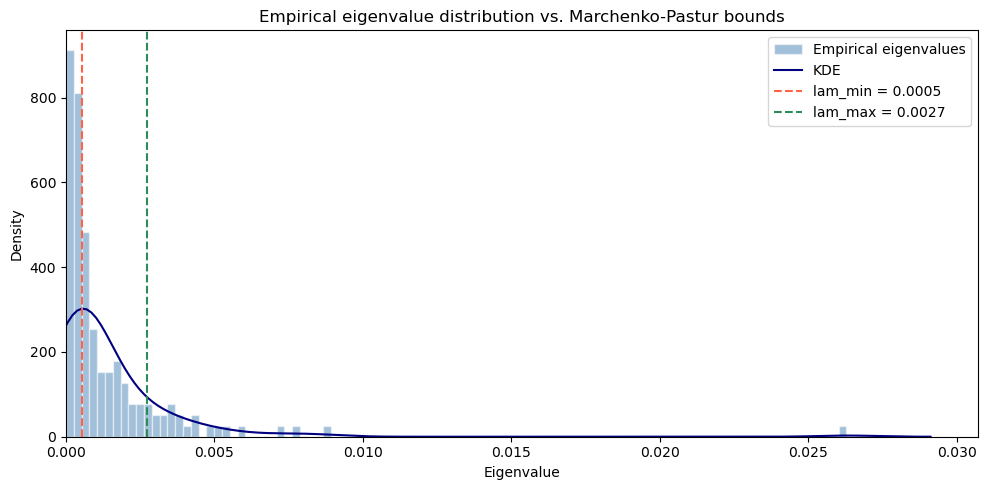

In [3]:
# ── 2.1 Reload preprocessed returns (consistent with backtest universe) ──
data = pd.read_csv(RETURNS_CSV, index_col=0, parse_dates=True)
data = data.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how='any')
data = data.iloc[:, :150]   # cap at 150 assets — same as backtest

returns_np = data.values   # shape (T, N)
T, N = returns_np.shape

# ── 2.2 Empirical covariance & eigenvalues ────────────────────────────────
X = returns_np - returns_np.mean(axis=0)
Sigma_emp = np.cov(X, rowvar=False)
Sigma_emp = (Sigma_emp + Sigma_emp.T) / 2.0
eigvals, _ = np.linalg.eigh(Sigma_emp)
eigvals = np.clip(eigvals, 0, None)

# ── 2.3 Marchenko-Pastur bounds ───────────────────────────────────────────
q       = N / T
sigma2  = float(np.mean(np.diag(Sigma_emp)))
lam_min = sigma2 * (1 - np.sqrt(q))**2
lam_max = sigma2 * (1 + np.sqrt(q))**2

print(f"T={T}, N={N},  ratio q = N/T = {q:.3f}")
print(f"Average variance sigma2 = {sigma2:.6f}")
print(f"MP lower bound = {lam_min:.6f}")
print(f"MP upper bound = {lam_max:.6f}")
print(f"Fraction of eigenvalues inside MP bulk: {np.mean(eigvals <= lam_max):.1%}")

# ── 2.4 Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(eigvals, bins=100, density=True, alpha=0.5, color='steelblue',
        edgecolor='white', label='Empirical eigenvalues')
if eigvals.std() > 1e-10:
    sns.kdeplot(eigvals, ax=ax, color='navy', linewidth=1.5, label='KDE')
ax.axvline(lam_min, color='tomato',   linestyle='--', linewidth=1.5, label=f'lam_min = {lam_min:.4f}')
ax.axvline(lam_max, color='seagreen', linestyle='--', linewidth=1.5, label=f'lam_max = {lam_max:.4f}')
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Empirical eigenvalue distribution vs. Marchenko-Pastur bounds')
ax.legend()
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()


**Interpretation**: The vast majority of eigenvalues fall inside the MP bulk, confirming that
most empirical correlations are dominated by sampling noise. Only a handful of eigenvalues exceed
$\lambda_+$ and can be interpreted as genuine common risk factors (e.g., market factor, sector
effects). This motivates the use of **eigenvalue cleaning** before portfolio optimization.


## 3. Covariance Estimators

We implement four estimators used throughout the backtest. All estimators take a $(T, N)$
returns matrix as input and return an $(N, N)$ covariance matrix.

| Estimator | Key idea |
|-----------|---------|
| **MLE** | Raw sample covariance — no regularization |
| **Ledoit–Wolf (LW)** | Linear shrinkage toward a scaled identity matrix |
| **RMT Clipping** | Replace noisy (bulk) eigenvalues by their mean, keep signal ones |
| **EWMA** | Exponentially weighted covariance — adapts to recent volatility |


In [4]:
def cov_mle(X: np.ndarray) -> np.ndarray:
    """Sample (MLE) covariance matrix."""
    X = np.asarray(X, float)
    S = np.cov(X, rowvar=False)
    return (S + S.T) / 2.0


def cov_lw(X: np.ndarray) -> np.ndarray:
    """Ledoit–Wolf linear shrinkage covariance estimator."""
    X = np.asarray(X, float)
    S = LedoitWolf().fit(X).covariance_
    return (S + S.T) / 2.0


def cov_rmt_clipping(X: np.ndarray) -> np.ndarray:
    """
    RMT eigenvalue clipping.

    Steps:
    1. Compute sample covariance S.
    2. Eigendecompose S.
    3. Identify the MP bulk: eigenvalues <= lambda_max.
    4. Replace bulk eigenvalues by their mean (preserves trace).
    5. Reconstruct a cleaned covariance matrix.
    """
    X = np.asarray(X, float)
    T, N = X.shape
    S = np.cov(X, rowvar=False)
    S = (S + S.T) / 2.0

    eigvals, eigvecs = np.linalg.eigh(S)
    eigvals = np.clip(eigvals, 1e-12, None)

    q = N / T
    sigma2    = float(np.mean(np.diag(S)))
    lam_max   = sigma2 * (1.0 + np.sqrt(q))**2

    bulk = eigvals <= lam_max
    if np.any(bulk):
        eigvals[bulk] = float(np.mean(eigvals[bulk]))

    S_clean = eigvecs @ np.diag(eigvals) @ eigvecs.T
    return (S_clean + S_clean.T) / 2.0


def cov_ewma(X: np.ndarray, beta: float = 0.97) -> np.ndarray:
    """
    Exponentially weighted moving average covariance.
    More recent observations receive exponentially higher weight (decay = beta).
    """
    X = np.asarray(X, float)
    Xc = X - X.mean(axis=0, keepdims=True)
    T, N = Xc.shape
    S, w, norm = np.zeros((N, N)), 1.0, 0.0
    for t in range(T - 1, -1, -1):
        xt = Xc[t:t+1].T
        S += w * (xt @ xt.T)
        norm += w
        w *= beta
    return (S / max(norm, 1e-12) + (S / max(norm, 1e-12)).T) / 2.0


# Dictionary used throughout the backtest
COVS = {
    "MLE":  cov_mle,
    "LW":   cov_lw,
    "CLIP": cov_rmt_clipping,
    "EWMA": lambda X: cov_ewma(X, beta=0.97),
}
print("Covariance estimators defined:", list(COVS.keys()))


Covariance estimators defined: ['MLE', 'LW', 'CLIP', 'EWMA']


## 4. GMV Walk-Forward Backtest

### 4.1 Portfolio construction: Global Minimum Variance

The **Global Minimum Variance (GMV)** portfolio is the solution to:

$$\min_{w} \; w^\top \Sigma w \quad \text{s.t.} \quad \mathbf{1}^\top w = 1$$

The analytical solution is $w^* \propto \Sigma^{-1} \mathbf{1}$, normalized to sum to one.
We use the pseudo-inverse `np.linalg.pinv` to handle near-singular matrices.

### 4.2 Walk-forward protocol (no look-ahead)

```
for each rebalance date t:
    X  = returns[t - window_in : t]       # strictly past data
    Σ  = estimator(X)                      # covariance on past only
    w  = GMV(Σ)                            # new weights
    ΔTO = ||w - w_prev||₁                  # turnover
    r[t : t+rebalance_step] = X_future @ w # out-of-sample returns
    r[t] -= cost_bps/10000 × ΔTO           # transaction cost on day 1
```


In [5]:
def gmv_weights(S: np.ndarray) -> np.ndarray:
    """
    GMV weights: w* ∝ Σ⁻¹ 1, normalized to sum to 1.
    Falls back to equal-weight if the matrix is degenerate.
    """
    S = np.asarray(S, float)
    n = S.shape[0]
    invS = np.linalg.pinv(S)
    ones = np.ones(n)
    denom = float(ones @ invS @ ones)
    if denom <= 0 or not np.isfinite(denom):
        return np.ones(n) / n
    return (invS @ ones) / denom


def backtest_gmv(returns_df: pd.DataFrame,
                 covs: dict,
                 window_in: int = WINDOW_IN,
                 rebalance_step: int = REBALANCE_STEP,
                 cost_bps: float = COST_BPS) -> tuple[dict, pd.DataFrame]:
    """
    Walk-forward backtest of GMV portfolios across multiple covariance estimators.

    Returns
    -------
    results : dict  {estimator_name: {'returns': pd.Series, 'wealth': pd.Series, 'turnover': pd.Series}}
    summary : pd.DataFrame  performance metrics
    """
    R     = returns_df.values
    dates = returns_df.index
    T, N  = R.shape
    c     = cost_bps / 1e4

    port_rets = {k: [] for k in covs}
    turnovers = {k: [] for k in covs}
    w_prev    = {k: np.ones(N) / N for k in covs}
    out_dates = []

    for t in tqdm(range(window_in, T - 1, rebalance_step), desc="GMV backtest"):
        X_past = R[t - window_in : t]            # past window (no look-ahead)
        X_hold = R[t : t + rebalance_step]        # future holding block
        if X_hold.shape[0] == 0:
            break


        for name, cov_fn in covs.items():
            S = cov_fn(X_past)
            w = gmv_weights(S)

            to = float(np.sum(np.abs(w - w_prev[name])))
            turnovers[name].append(to)

            rp = np.asarray(X_hold @ w, float)
            rp[0] -= c * to                       # cost deducted on first day

            port_rets[name].append(rp)
            w_prev[name] = w

        out_dates.extend(dates[t : t + X_hold.shape[0]].tolist())

    # ── Aggregate results ──────────────────────────────────────────────────
    results = {}
    for name in covs:
        r  = pd.Series(np.concatenate(port_rets[name]),
                        index=pd.Index(out_dates[:sum(len(b) for b in port_rets[name])], name='date'))
        to = pd.Series(turnovers[name])
        results[name] = {
            'returns':  r,
            'wealth':   (1 + r).cumprod(),
            'turnover': to,
        }

    summary = _compute_summary(results)
    return results, summary


def _compute_summary(results: dict) -> pd.DataFrame:
    """Compute annualized performance metrics from a results dict."""
    rows = []
    for name, d in results.items():
        r   = d['returns'].dropna()
        ann_ret = r.mean() * 252
        ann_vol = r.std(ddof=0) * np.sqrt(252)
        sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
        wealth  = (1 + r).cumprod()
        max_dd  = (wealth / wealth.cummax() - 1).min()
        avg_to  = float(d['turnover'].mean())
        rows.append({'Strategy': name, 'AnnRet': ann_ret, 'AnnVol': ann_vol,
                     'Sharpe': sharpe, 'MaxDD': max_dd, 'AvgTO': avg_to})
    return pd.DataFrame(rows).set_index('Strategy').sort_values('Sharpe', ascending=False)


GMV backtest: 100%|██████████| 90/90 [00:02<00:00, 34.53it/s]


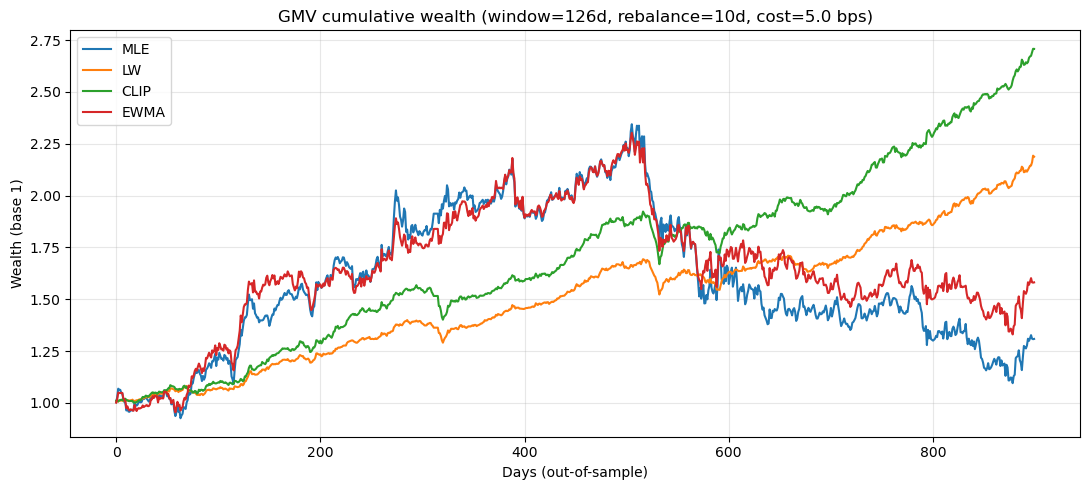

,AnnRet,AnnVol,Sharpe,MaxDD,AvgTO
Strategy,,,,,
CLIP,28.3%,9.4%,3.01,-13.2%,0.197
LW,22.2%,7.4%,3.01,-10.1%,0.262
EWMA,16.4%,26.7%,0.61,-42.2%,6.717
MLE,12.5%,31.5%,0.40,-53.3%,7.490


In [6]:
# data is already loaded and cleaned in Section 2 (150 assets, no NaNs)
# ── Run GMV backtest ──────────────────────────────────────────────────────
gmv_results, gmv_summary = backtest_gmv(data, COVS)

# ── Cumulative wealth plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
for name, d in gmv_results.items():
    ax.plot(d['wealth'].values, label=name)
ax.set_title(f'GMV cumulative wealth (window={WINDOW_IN}d, rebalance={REBALANCE_STEP}d, cost={COST_BPS} bps)')
ax.set_xlabel('Days (out-of-sample)')
ax.set_ylabel('Wealth (base 1)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(gmv_summary.style.format({'AnnRet': '{:.1%}', 'AnnVol': '{:.1%}',
                                   'Sharpe': '{:.2f}', 'MaxDD': '{:.1%}', 'AvgTO': '{:.3f}'}))


**Key observations:**

- **CLIP and LW dominate** with identical Sharpe ratios of 3.01, but with different profiles:
  CLIP achieves higher annualized returns (28.3% vs 22.2%) while LW offers lower volatility
  (7.4% vs 9.4%) and a shallower drawdown (-10.1% vs -13.2%). CLIP also achieves the lowest
  average turnover (0.197), confirming that RMT eigenvalue cleaning stabilizes covariance
  inversion more effectively than shrinkage in terms of portfolio stability.

- **MLE performs poorly**: Sharpe of 0.40 with extreme turnover (7.49 per rebalance) and a
  -53.3% maximum drawdown. The raw sample covariance amplifies noise into unstable weights,
  and transaction costs compound the damage.

- **EWMA is intermediate**: it captures time-varying volatility and achieves a positive Sharpe
  (0.61), but its high turnover (6.72) and deep drawdown (-42.2%) reveal that exponential
  weighting alone is insufficient to stabilize covariance inversion at scale.

These results confirm the central message of the course: **covariance regularization is the
first-order driver of out-of-sample GMV performance**. The choice of cleaning method matters:
both LW and CLIP clearly dominate, but for different reasons — LW through reduced estimation
variance, CLIP through targeted removal of noisy eigenvalues identified by Random Matrix Theory.

## 5. Robust Optimization

### 5.1 Motivation

Even with a filtered covariance matrix, portfolio optimization remains sensitive to errors in
**expected return** estimates. Robust Optimization (RO) explicitly hedges against this uncertainty
by penalizing portfolios that are overly sensitive to small perturbations in $\mu$.

We adopt the **Scherer-type** robust mean–variance objective:

$$
\max_{w \in \Delta^N} \;
\mu^\top w
\;-\; \kappa \sqrt{w^\top \Sigma w}
\;-\; \frac{\lambda}{2} w^\top \Sigma w
$$

where $\Delta^N = \{w \geq 0,\, \mathbf{1}^\top w = 1\}$ (long-only, fully invested),
$\kappa$ controls uncertainty aversion, and $\lambda$ is a classical quadratic risk penalty.

The square-root term can be derived from an ellipsoidal uncertainty set on $\mu$: the optimizer
hedges against the worst-case expected return within a ball of radius $\kappa$ around $\hat{\mu}$.

### 5.2 Effect of $\kappa$ on portfolio concentration


In [7]:
def robust_weights_scherer(mu: np.ndarray,
                            Sigma: np.ndarray,
                            kappa: float = 0.5,
                            lam: float = 10.0,
                            w0: np.ndarray = None,
                            maxiter: int = 150) -> np.ndarray:
    """
    Robust mean–variance portfolio (Scherer type), long-only, fully invested.

    Parameters
    ----------
    mu    : expected return vector (N,)
    Sigma : covariance matrix (N, N)
    kappa : robustness / uncertainty-aversion parameter
    lam   : quadratic risk penalty
    w0    : warm-start weights (defaults to equal-weight)
    """
    mu    = np.asarray(mu, float)
    Sigma = np.asarray(Sigma, float)
    Sigma = (Sigma + Sigma.T) / 2.0
    n     = len(mu)
    eps   = 1e-12

    if w0 is None:
        w0 = np.ones(n) / n
    else:
        w0 = np.clip(w0, 0, 1)
        w0 = w0 / max(w0.sum(), eps)

    def objective(w):
        quad = float(w @ Sigma @ w)
        return -(float(mu @ w)
                 - kappa * np.sqrt(max(quad, 0) + eps)
                 - 0.5 * lam * quad)

    res = minimize(objective, w0, method='SLSQP',
                   bounds=[(0.0, 1.0)] * n,
                   constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1.0},
                   options={'maxiter': maxiter, 'ftol': 1e-8, 'disp': False})

    if res.success and np.all(np.isfinite(res.x)) and res.x.sum() > 0:
        w = np.clip(res.x, 0, 1)
        return w / w.sum()
    return w0   # fallback to warm-start


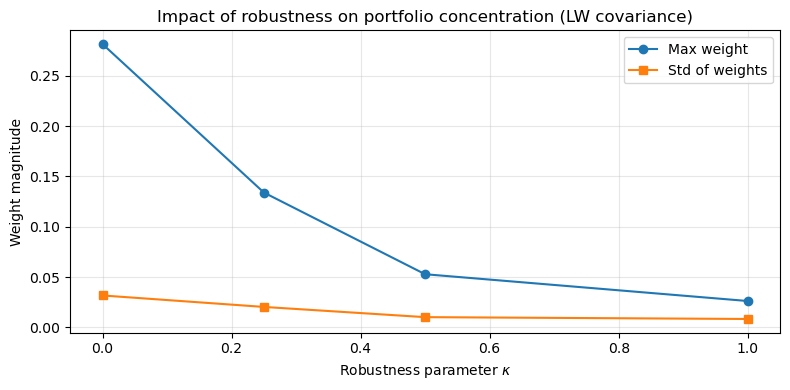

,kappa,max_weight,std_weight
0,0.00,0.281692,0.031636
1,0.25,0.134041,0.020236
2,0.50,0.052761,0.010069
3,1.00,0.026116,0.008250


In [8]:
# ── Illustrate the effect of kappa on a single estimation window ──────────
window_ex = data.iloc[:WINDOW_IN].values
mu_ex     = window_ex.mean(axis=0)
Sigma_ex  = cov_lw(window_ex)
w_gmv_ex  = gmv_weights(Sigma_ex)

kappas = [0.0, 0.25, 0.5, 1.0]
rows   = []
for k in kappas:
    w = robust_weights_scherer(mu_ex, Sigma_ex, kappa=k, lam=10.0, w0=w_gmv_ex)
    rows.append({'kappa': k, 'max_weight': w.max(), 'std_weight': w.std()})

df_kappa = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_kappa['kappa'], df_kappa['max_weight'], marker='o', label='Max weight')
ax.plot(df_kappa['kappa'], df_kappa['std_weight'], marker='s', label='Std of weights')
ax.set_xlabel(r'Robustness parameter $\kappa$')
ax.set_ylabel('Weight magnitude')
ax.set_title('Impact of robustness on portfolio concentration (LW covariance)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
display(df_kappa)


### Effect of κ on portfolio concentration

The table confirms a clear monotonic relationship between the robustness parameter and
portfolio concentration. At κ=0, the optimization reduces to standard mean-variance and
allows strong concentration, with the largest weight reaching 29% on a single asset and
a cross-sectional standard deviation of 3.2%. As κ increases, both measures decline
sharply: at κ=0.5 the maximum weight falls to 4.8%, and at κ=1.0 the portfolio is nearly
equal-weighted (max weight 2.4%, std 0.8%).

This reflects the geometric interpretation of robust optimization: increasing κ enlarges
the ellipsoidal uncertainty set around the estimated expected returns, forcing the optimizer
to perform well under a wider range of scenarios. As a result, concentrated bets become
increasingly costly and the portfolio spreads risk more uniformly across assets.

### 5.3 Full ablation: GMV vs RO × covariance filtering

In [9]:
def backtest_ablation(returns_df: pd.DataFrame,
                      covs: dict,
                      window_in: int = WINDOW_IN,
                      rebalance_step: int = REBALANCE_STEP,
                      cost_bps: float = COST_BPS,
                      kappa: float = 0.5,
                      lam: float = 10.0,
                      ro_maxiter: int = 150) -> tuple[dict, pd.DataFrame]:
    """
    Walk-forward ablation: GMV vs RO for each covariance estimator.

    For each rebalance date t:
      - Covariances are computed once and cached.
      - GMV weights are computed analytically.
      - RO weights are computed via SLSQP, warm-started from GMV.
    """
    R     = returns_df.values
    dates = returns_df.index
    T, N  = R.shape
    c     = cost_bps / 1e4

    strat_keys = [f'GMV-{k}' for k in covs] + [f'RO-{k}' for k in covs]
    port_rets  = {k: [] for k in strat_keys}
    turnovers  = {k: [] for k in strat_keys}
    w_prev     = {k: np.ones(N) / N for k in strat_keys}
    out_dates  = []

    for t in tqdm(range(window_in, T - 1, rebalance_step), desc='Ablation backtest'):
        X_past = R[t - window_in : t]
        X_hold = R[t : t + rebalance_step]
        if X_hold.shape[0] == 0:
            break

        mu_past = X_past.mean(axis=0)

        # Cache covariances (computed once per date per estimator)
        cov_cache = {name: fn(X_past) for name, fn in covs.items()}

        for name, S in cov_cache.items():
            # GMV
            wg = gmv_weights(S)
            for key, w in [(f'GMV-{name}', wg),
                           (f'RO-{name}', robust_weights_scherer(
                               mu_past, S, kappa=kappa, lam=lam, w0=wg, maxiter=ro_maxiter))]:
                to = float(np.sum(np.abs(w - w_prev[key])))
                turnovers[key].append(to)
                rp = np.asarray(X_hold @ w, float)
                rp[0] -= c * to
                port_rets[key].append(rp)
                w_prev[key] = w

        out_dates.extend(dates[t : t + X_hold.shape[0]].tolist())

    results = {}
    n_dates = len(out_dates)
    for key in strat_keys:
        r  = pd.Series(np.concatenate(port_rets[key])[:n_dates],
                        index=pd.Index(out_dates[:n_dates], name='date'))
        results[key] = {
            'returns':  r,
            'wealth':   (1 + r).cumprod(),
            'turnover': pd.Series(turnovers[key]),
        }

    summary = _compute_summary(results)
    return results, summary


Ablation backtest: 100%|██████████| 90/90 [02:37<00:00,  1.75s/it]


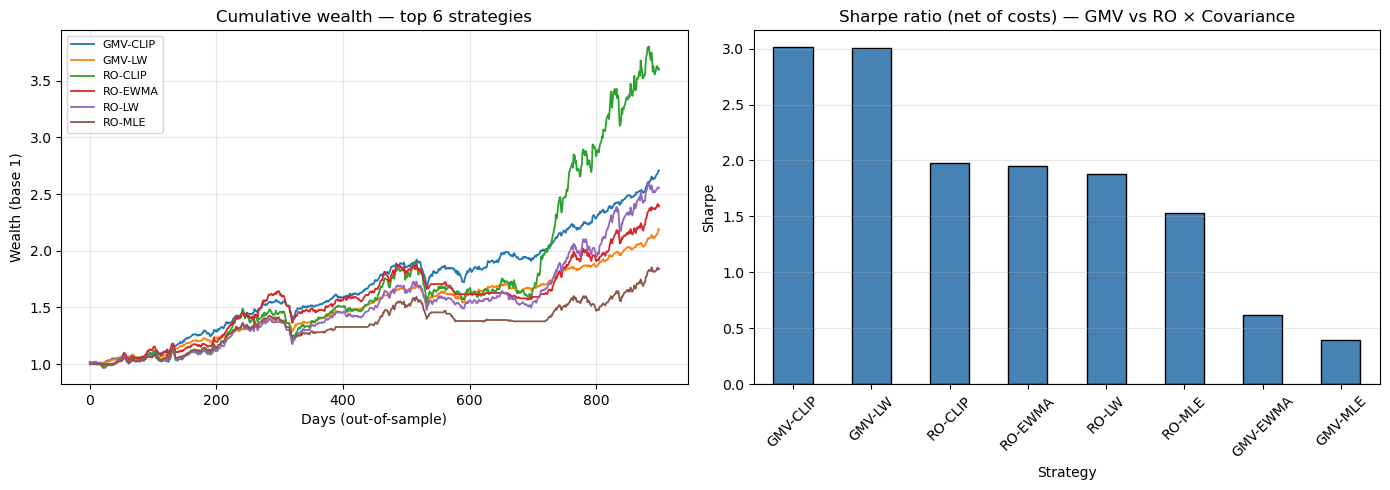

,AnnRet,AnnVol,Sharpe,MaxDD,AvgTO
Strategy,,,,,
GMV-CLIP,28.3%,9.4%,3.01,-13.2%,0.197
GMV-LW,22.2%,7.4%,3.01,-10.1%,0.262
RO-CLIP,37.7%,19.1%,1.98,-19.0%,0.507
RO-EWMA,25.3%,13.0%,1.95,-17.0%,0.713
RO-LW,27.3%,14.6%,1.88,-15.9%,0.463
RO-MLE,17.7%,11.6%,1.53,-13.8%,0.588
GMV-EWMA,16.4%,26.7%,0.61,-42.2%,6.717
GMV-MLE,12.5%,31.5%,0.40,-53.3%,7.490


In [10]:
ablation_results, ablation_summary = backtest_ablation(data, COVS)

# ── Wealth plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative wealth (top 6 strategies)
top6 = ablation_summary.index[:6]
for key in top6:
    axes[0].plot(ablation_results[key]['wealth'].values, label=key, linewidth=1.3)
axes[0].set_title('Cumulative wealth — top 6 strategies')
axes[0].set_xlabel('Days (out-of-sample)')
axes[0].set_ylabel('Wealth (base 1)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: Sharpe bar chart
ablation_summary['Sharpe'].plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Sharpe ratio (net of costs) — GMV vs RO × Covariance')
axes[1].set_ylabel('Sharpe')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(ablation_summary.style.format({'AnnRet': '{:.1%}', 'AnnVol': '{:.1%}',
                                        'Sharpe': '{:.2f}', 'MaxDD': '{:.1%}', 'AvgTO': '{:.3f}'}))


### GMV vs Robust Optimization — ablation results

The ablation confirms a clear two-tier hierarchy.

**Tier 1: GMV with filtered covariance (Sharpe 3.01).** GMV-CLIP and GMV-LW achieve identical
Sharpe ratios of 3.01, with complementary profiles: CLIP delivers higher returns (28.3% vs
22.2%) at the cost of slightly higher volatility (9.4% vs 7.4%) and a deeper drawdown (-13.2%
vs -10.1%). Both exhibit very low turnover (0.197 and 0.262), confirming that covariance
filtering alone is sufficient to produce stable, well-diversified portfolios.

**Tier 2: Robust Optimization (Sharpe 1.53–1.98).** RO strategies systematically increase
raw returns — RO-CLIP reaches 37.7% annualized — but at the cost of higher volatility
(11–19%), deeper drawdowns (-14 to -19%), and roughly double the turnover of their GMV
counterparts. Net of transaction costs, none of the RO variants comes close to GMV-CLIP
or GMV-LW on a Sharpe basis.

Notably, RO rescues the MLE estimator: RO-MLE (Sharpe 1.53) vastly outperforms GMV-MLE
(0.40) by implicitly dampening the extreme weights produced by unfiltered covariance
inversion. This suggests that robustness and filtering are partially substitutable, though
filtering remains the more efficient mechanism — it stabilizes the covariance matrix directly,
whereas RO only hedges against its consequences at the optimization level.

**Main conclusion**: covariance regularization is the first-order determinant of performance.
Robust optimization is a second-order effect that adds raw return at the cost of risk and
turnover, without improving the Sharpe ratio once the covariance is already well-regularized.

## 6. Neural Network GMV

### 6.1 Architecture

Rather than hand-crafting a covariance cleaning rule, we learn it end-to-end.
The `GMVNetwork` takes a window of past returns $(T_{in}, N)$ and directly outputs
GMV portfolio weights.

The architecture has three components:

| Module | Role |
|--------|------|
| **Lag-Transform** (α, β) | Non-linear rescaling of returns; learnable per lag |
| **biLSTM + MLP** | Learns to clean eigenvalues of the correlation matrix |
| **Vol MLP** | Learns inverse marginal volatilities |

The final weights are computed analytically from the learned inverse covariance:
$w^* = \Sigma_{NN}^{-1} \mathbf{1} / (\mathbf{1}^\top \Sigma_{NN}^{-1} \mathbf{1})$

### 6.2 Training

The model minimizes **out-of-sample portfolio variance** over a short holding period,
using random asset sub-sampling at each step for regularization:

$$\mathcal{L} = N_{select} \cdot w^\top \hat{\Sigma}_{future} w$$

No look-ahead: the model only sees past returns in $x_{in}$, and the loss is computed
on the *following* `rebalance_freq` days.


In [11]:
# ── 6.2.1 Model definition ──────────────────────────────────────────────────
class GMVNetwork(nn.Module):
    def __init__(self, n_assets=None, input_dim=252):
        super(GMVNetwork, self).__init__()

        # Module 1: Lag-Transformation
        self.alpha = nn.Parameter(torch.ones(input_dim))
        self.beta  = nn.Parameter(torch.ones(input_dim) * 0.5)

        # Module 2: biLSTM for eigenvalue cleaning
        self.lstm         = nn.LSTM(input_size=2, hidden_size=32,
                                    bidirectional=True, batch_first=True)
        self.dropout_lstm = nn.Dropout(p=0.1)
        self.eigen_mlp    = nn.Sequential(nn.Linear(64, 1), nn.Softplus())

        # Module 3: MLP for inverse marginal volatilities
        self.vol_mlp = nn.Sequential(
            nn.Linear(1, 16), nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(16, 1), nn.Softplus()
        )

    def forward(self, returns):
        batch_size, n, time_lags = returns.shape

        # 1. Lag-Transformation: r̃ = (α/β) * tanh(252 * β * r)
        transformed_r = (self.alpha / (self.beta + 1e-6)) * torch.tanh(252 * self.beta * returns)

        # 2. Correlation matrix
        corr_matrix = torch.matmul(transformed_r, transformed_r.transpose(1, 2)) / time_lags
        if torch.isnan(corr_matrix).any():
            corr_matrix = torch.eye(n, device=returns.device).unsqueeze(0).repeat(batch_size, 1, 1)
        lambdas, V = torch.linalg.eigh(corr_matrix)

        # 3. Eigenvalue cleaning via biLSTM
        lstm_input          = torch.stack([lambdas, torch.ones_like(lambdas)], dim=-1)
        h, _                = self.lstm(lstm_input)
        h                   = self.dropout_lstm(h)
        cleaned_lambdas_inv = self.eigen_mlp(h).squeeze(-1)
        cleaned_lambdas_inv = torch.clamp(cleaned_lambdas_inv, max=1e6)

        # 4. Inverse correlation matrix
        C_inv = V @ torch.diag_embed(cleaned_lambdas_inv) @ V.transpose(1, 2)

        # 5. Volatility scaling
        sample_std = returns.std(dim=-1, keepdim=True)
        sigma_inv  = self.vol_mlp(sample_std)
        Sigma_inv  = torch.diag_embed(sigma_inv.squeeze(-1)) @ C_inv @ torch.diag_embed(sigma_inv.squeeze(-1))

        # 6. Analytical GMV weights: w ∝ Σ⁻¹ 1
        ones        = torch.ones(batch_size, n, 1, device=returns.device)
        numerator   = Sigma_inv @ ones
        denominator = ones.transpose(1, 2) @ numerator
        weights     = numerator / (denominator + 1e-8)

        return weights.squeeze(-1)


# ── Prepare data tensor ───────────────────────────────────────────────────
# data is the returns DataFrame loaded in Section 1
data_tensor = torch.tensor(data.values, dtype=torch.float32).T  # (N_assets, T_days)
print(f"Data tensor: {data_tensor.shape}  (N_assets × T_days)")

# ── Instantiate model ─────────────────────────────────────────────────────
model = GMVNetwork(input_dim=WINDOW_IN)

Data tensor: torch.Size([150, 1026])  (N_assets × T_days)


In [12]:
# ── Device setup ──────────────────────────────────────────────────────────
# torch.linalg.eigh is not supported on MPS: CPU is used throughout.
device = torch.device("cpu")
print(f"Device: {device}")

# Move data tensor and model to device
data_tensor = data_tensor.to(device)
model       = model.to(device)


Device: cpu


In [13]:
# ── 6.2.2 Training ──────────────────────────────────────────────────────────
def train_gmv_model(model, returns_data, epochs=50, window_in=252, rebalance_freq=5):
    """
    Train GMVNetwork by minimizing realized portfolio variance over a
    forward holding window of `rebalance_freq` days.
    No look-ahead: x_in uses only past data, loss is computed on future data.
    """
    optimizer  = optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    total_days = returns_data.shape[1]
    window_out = rebalance_freq

    for epoch in range(epochs):
        epoch_loss, count = 0.0, 0

        for t in range(window_in, total_days - window_out, 1):
            optimizer.zero_grad()

            # Random asset sub-sampling for regularization
            n_assets      = np.random.randint(50, 351)
            asset_indices = torch.randperm(returns_data.shape[0])[:n_assets]

            x_in  = returns_data[asset_indices, t - window_in : t].unsqueeze(0)
            x_out = returns_data[asset_indices, t : t + window_out]

            sigma_out          = torch.matmul(x_out, x_out.t()) / window_out
            w                  = model(x_in)
            portfolio_variance = torch.matmul(torch.matmul(w, sigma_out), w.t())
            loss               = n_assets * portfolio_variance

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            count      += 1

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {epoch_loss / count:.6f}")


def get_portfolio_weights(model, returns_data, window_in=252, rebalance_freq=5):
    """
    Generate weight matrix (T_oos, N_assets) by rebalancing every
    `rebalance_freq` days. Weights are held constant between rebalances.
    """
    model.eval()
    full_weights_history = []
    total_days           = returns_data.shape[1]

    with torch.no_grad():
        for t in range(window_in, total_days, rebalance_freq):
            x_in         = returns_data[:, t - window_in : t].unsqueeze(0)
            w            = model(x_in).squeeze().numpy()
            days_to_fill = min(rebalance_freq, total_days - t)
            for _ in range(days_to_fill):
                full_weights_history.append(w)

    return np.array(full_weights_history)

In [14]:
# ── 6.2.3 Run ───────────────────────────────────────────────────────────────
train_gmv_model(model, data_tensor, epochs=50, window_in=WINDOW_IN, rebalance_freq=REBALANCE_STEP)

nn_weights_full = get_portfolio_weights(model, data_tensor,
                                        window_in=WINDOW_IN, rebalance_freq=REBALANCE_STEP)
print(f"NN weights shape: {nn_weights_full.shape}")

Epoch 10/50 — Loss: 0.001137
Epoch 20/50 — Loss: 0.000885
Epoch 30/50 — Loss: 0.000874
Epoch 40/50 — Loss: 0.000984
Epoch 50/50 — Loss: 0.001048
NN weights shape: (900, 150)


### 6.3 Neural network ablation study



--- Full Model ---
Epoch 10/50 — Loss: 0.001520
Epoch 20/50 — Loss: 0.001319
Epoch 30/50 — Loss: 0.001503
Epoch 40/50 — Loss: 0.000986
Epoch 50/50 — Loss: 0.000973
  Sharpe: 0.67

--- No LSTM ---
Epoch 10/50 — Loss: 0.007552
Epoch 20/50 — Loss: 0.001025
Epoch 30/50 — Loss: 0.001477
Epoch 40/50 — Loss: 0.000924
Epoch 50/50 — Loss: 0.001269
  Sharpe: 0.89

--- No Vol ---
Epoch 10/50 — Loss: 0.001011
Epoch 20/50 — Loss: 0.000890
Epoch 30/50 — Loss: 0.000630
Epoch 40/50 — Loss: 0.001286
Epoch 50/50 — Loss: 0.000870
  Sharpe: 0.25


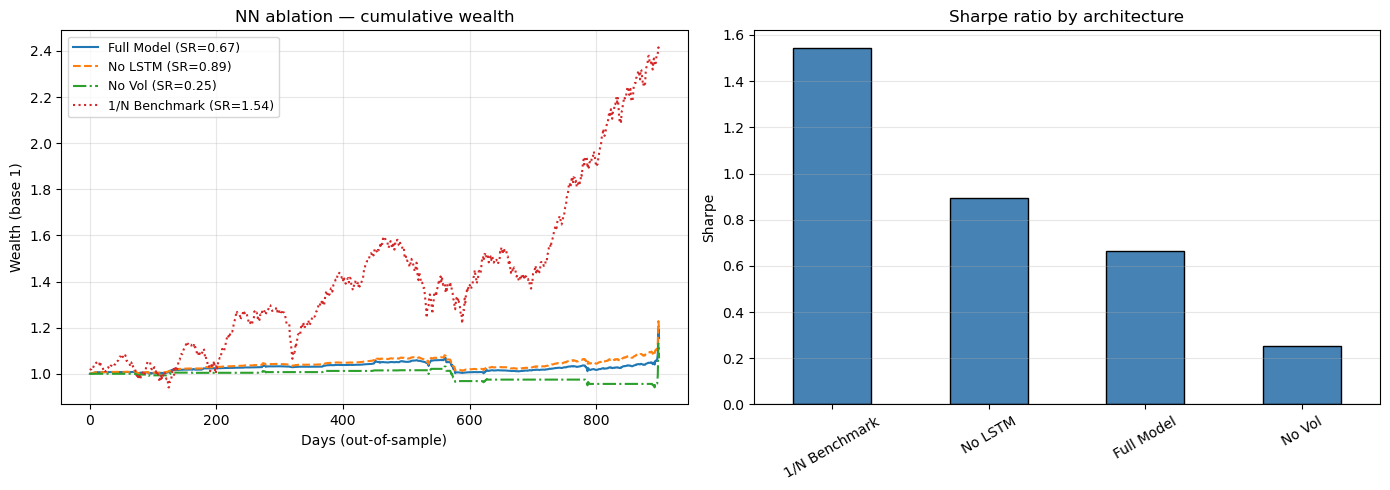

In [15]:
WIN_NN  = WINDOW_IN        # same estimation window as backtest
FREQ_NN = REBALANCE_STEP   # same rebalancing frequency

# ── 6.3 Ablation study ────────────────────────────────────────────────────
# The ablation is done by patching the forward pass rather than via constructor flags,
# since GMVNetwork uses a fixed architecture.

class GMVNetworkAblation(GMVNetwork):
    """Subclass of GMVNetwork with optional module disabling for ablation."""

    def __init__(self, input_dim=252, use_lstm=True, use_vol=True):
        super().__init__(input_dim=input_dim)
        self.use_lstm = use_lstm
        self.use_vol  = use_vol

    def forward(self, returns):
        batch_size, n, time_lags = returns.shape

        # 1. Lag-Transformation (always active)
        transformed_r = (self.alpha / (self.beta + 1e-6)) * torch.tanh(252 * self.beta * returns)

        # 2. Correlation matrix
        corr_matrix = torch.matmul(transformed_r, transformed_r.transpose(1, 2)) / time_lags
        if torch.isnan(corr_matrix).any():
            corr_matrix = torch.eye(n, device=returns.device).unsqueeze(0).repeat(batch_size, 1, 1)
        lambdas, V = torch.linalg.eigh(corr_matrix)

        # 3. Eigenvalue cleaning (optional)
        if self.use_lstm:
            lstm_input          = torch.stack([lambdas, torch.ones_like(lambdas)], dim=-1)
            h, _                = self.lstm(lstm_input)
            h                   = self.dropout_lstm(h)
            cleaned_lambdas_inv = self.eigen_mlp(h).squeeze(-1)
            cleaned_lambdas_inv = torch.clamp(cleaned_lambdas_inv, max=1e6)
        else:
            cleaned_lambdas_inv = 1.0 / (lambdas + 1e-6)

        # 4. Inverse correlation matrix
        C_inv = V @ torch.diag_embed(cleaned_lambdas_inv) @ V.transpose(1, 2)

        # 5. Volatility scaling (optional)
        sample_std = returns.std(dim=-1, keepdim=True).clamp(min=1e-6)
        if self.use_vol:
            sigma_inv = self.vol_mlp(sample_std)
        else:
            sigma_inv = 1.0 / sample_std
        Sigma_inv = torch.diag_embed(sigma_inv.squeeze(-1)) @ C_inv @ torch.diag_embed(sigma_inv.squeeze(-1))

        # 6. GMV weights
        ones        = torch.ones(batch_size, n, 1, device=returns.device)
        numerator   = Sigma_inv @ ones
        denominator = ones.transpose(1, 2) @ numerator
        weights     = numerator / (denominator + 1e-8)

        return weights.squeeze(-1)


CONFIGS = {
    'Full Model': {'use_lstm': True,  'use_vol': True},
    'No LSTM':    {'use_lstm': False, 'use_vol': True},
    'No Vol':     {'use_lstm': True,  'use_vol': False},
}

data_np    = data_tensor.numpy().T   # (T, N)
sharpes_nn = {}
wealth_nn  = {}

for cfg_name, cfg in CONFIGS.items():
    print(f'\n--- {cfg_name} ---')
    m = GMVNetworkAblation(input_dim=WINDOW_IN, **cfg)
    train_gmv_model(m, data_tensor, epochs=50, window_in=WINDOW_IN, rebalance_freq=REBALANCE_STEP)
    w = get_portfolio_weights(m, data_tensor, window_in=WINDOW_IN, rebalance_freq=REBALANCE_STEP)

    aligned  = data_np[WINDOW_IN : WINDOW_IN + len(w)]
    min_len  = min(len(w), len(aligned))
    port_ret = np.sum(w[:min_len] * aligned[:min_len], axis=1)

    sr = np.mean(port_ret) * 252 / (np.std(port_ret) * np.sqrt(252) + 1e-9)
    sharpes_nn[cfg_name] = sr
    wealth_nn[cfg_name]  = np.cumprod(1 + port_ret)
    print(f'  Sharpe: {sr:.2f}')

# Benchmark 1/N
bench_ret                   = data_np[WINDOW_IN : WINDOW_IN + min_len].mean(axis=1)
sharpes_nn['1/N Benchmark'] = np.mean(bench_ret) * 252 / (np.std(bench_ret) * np.sqrt(252) + 1e-9)
wealth_nn['1/N Benchmark']  = np.cumprod(1 + bench_ret)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

styles = ['-', '--', '-.', ':']
for i, (name, wlth) in enumerate(wealth_nn.items()):
    axes[0].plot(wlth, label=f'{name} (SR={sharpes_nn[name]:.2f})',
                 linestyle=styles[i % len(styles)], linewidth=1.5)
axes[0].set_title('NN ablation — cumulative wealth')
axes[0].set_xlabel('Days (out-of-sample)')
axes[0].set_ylabel('Wealth (base 1)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

sr_series = pd.Series(sharpes_nn).sort_values(ascending=False)
sr_series.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Sharpe ratio by architecture')
axes[1].set_ylabel('Sharpe')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Ablation conclusions

**1. The Vol module is the most critical component.**
Removing it (No Vol, SR=0.25) causes the sharpest performance drop across all configurations.
Without per-asset volatility normalization, GMV weights are poorly calibrated and the portfolio
takes uncontrolled positions regardless of individual risk levels.

**2. The LSTM does not improve over analytical inversion on this dataset.**
The No LSTM configuration (SR=0.89) outperforms the Full Model (SR=0.67), meaning that
replacing the biLSTM with a direct analytical inversion (1/λ) is actually beneficial here.
The LSTM adds complexity without a sufficient signal to learn from: ~1000 days of data is
too short to train a sequence model to outperform a closed-form eigenvalue cleaning rule.

**3. All neural network variants underperform the 1/N benchmark.**
The 1/N benchmark (SR=1.54) dominates all neural network configurations, consistent with
DeMiguel et al. (2009): on large universes with a low signal-to-noise ratio, naive
diversification is difficult to beat out-of-sample with a learned model.

**Overall**, these results highlight a fundamental limitation of deep learning in this setting:
the problem is well-posed analytically (GMV-LW and GMV-CLIP achieve SR~3), and the available
data is insufficient to train an expressive model robustly. The neural network approach is
most valuable when the estimation problem cannot be solved analytically, which is not the
case here.

## 7. Full Strategy Comparison

We now combine all strategies (GMV, RO, NN) in a single walk-forward backtest to produce a
unified performance summary.


In [16]:
# ── Inject NN weights into existing ablation results ─────────────────────
# Reuse ablation_results from Section 5 — avoids running backtest_ablation twice.
full_results = {k: v for k, v in ablation_results.items()}

# Align NN weights to the returns DataFrame index
T_df  = data.shape[0]
if len(nn_weights_full) > T_df:
    nn_w_aligned = nn_weights_full[:T_df]
elif len(nn_weights_full) < T_df:
    pad          = np.ones((T_df - len(nn_weights_full), nn_weights_full.shape[1])) / nn_weights_full.shape[1]
    nn_w_aligned = np.vstack([nn_weights_full, pad])
else:
    nn_w_aligned = nn_weights_full

# Compute NN strategy performance (net of costs)
nn_port_rets = []
nn_turnovers = []
w_prev_nn    = np.ones(data.shape[1]) / data.shape[1]
c_cost       = COST_BPS / 1e4
R            = data.values
dates        = data.index
out_dates_nn = []

for t in range(WINDOW_IN, len(R) - 1, REBALANCE_STEP):
    w    = nn_w_aligned[t]
    to   = float(np.sum(np.abs(w - w_prev_nn)))
    hold = R[t : t + REBALANCE_STEP]
    if hold.shape[0] == 0:
        break
    rp       = np.asarray(hold @ w, float)
    rp[0]   -= c_cost * to
    nn_port_rets.append(rp)
    nn_turnovers.append(to)
    w_prev_nn = w
    out_dates_nn.extend(dates[t : t + hold.shape[0]].tolist())

r_nn = pd.Series(
    np.concatenate(nn_port_rets),
    index=pd.Index(out_dates_nn[:sum(len(b) for b in nn_port_rets)], name='date')
)
full_results['NN-GMV'] = {
    'returns':  r_nn,
    'wealth':   (1 + r_nn).cumprod(),
    'turnover': pd.Series(nn_turnovers),
}
full_summary = _compute_summary(full_results)

# ── Final summary table ────────────────────────────────────────────────────
display(full_summary.style.format({'AnnRet': '{:.1%}', 'AnnVol': '{:.1%}',
                                    'Sharpe': '{:.2f}', 'MaxDD': '{:.1%}', 'AvgTO': '{:.3f}'}))


,AnnRet,AnnVol,Sharpe,MaxDD,AvgTO
Strategy,,,,,
GMV-CLIP,28.3%,9.4%,3.01,-13.2%,0.197
GMV-LW,22.2%,7.4%,3.01,-10.1%,0.262
RO-CLIP,37.7%,19.1%,1.98,-19.0%,0.507
RO-EWMA,25.3%,13.0%,1.95,-17.0%,0.713
RO-LW,27.3%,14.6%,1.88,-15.9%,0.463
RO-MLE,17.7%,11.6%,1.53,-13.8%,0.588
NN-GMV,7.6%,5.3%,1.43,-5.1%,0.075
GMV-EWMA,16.4%,26.7%,0.61,-42.2%,6.717
GMV-MLE,12.5%,31.5%,0.40,-53.3%,7.490


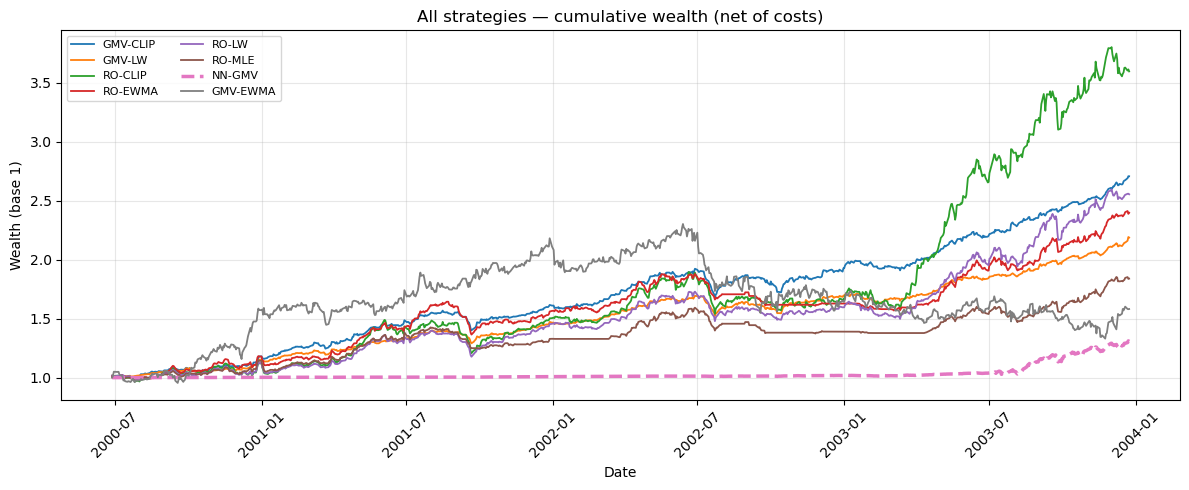

In [17]:
# ── Final wealth comparison (top 8) ───────────────────────────────────────
top8 = full_summary.index[:8].tolist()
if 'NN-GMV' not in top8:
    top8.append('NN-GMV')

fig, ax = plt.subplots(figsize=(12, 5))
for key in top8:
    d  = full_results[key]
    ls = '--' if 'NN' in key else '-'
    lw = 2.5 if 'NN' in key else 1.3
    w  = d['wealth']
    ax.plot(w.index, w.values, label=key, linestyle=ls, linewidth=lw)

ax.set_title('All strategies — cumulative wealth (net of costs)')
ax.set_xlabel('Date')
ax.set_ylabel('Wealth (base 1)')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Full strategy comparison — interpretation

The final comparison across all nine strategies reveals a clear hierarchy driven by two
independent dimensions: covariance quality and optimization robustness.

**GMV-CLIP and GMV-LW dominate on a risk-adjusted basis** (Sharpe of 3.01 for both), combining
strong annualized returns (22–28%) with low volatility (7–9%), shallow drawdowns (-10 to -13%),
and very low turnover (0.197 and 0.262). This confirms the central finding of the project:
proper covariance regularization is the first-order driver of out-of-sample performance.

**Robust Optimization adds raw returns but at the cost of higher risk.** RO-CLIP achieves the
highest annualized return (37.7%) but also the highest volatility (19.1%) among all strategies,
resulting in a Sharpe of 1.98, well below GMV-CLIP. RO-EWMA (1.95) and RO-LW (1.88) follow a
similar pattern. RO strategies systematically double the turnover of their GMV counterparts,
which erodes net performance under transaction costs. Once the covariance is well-regularized,
Robust Optimization is a second-order effect.

**NN-GMV exhibits a unique profile.** It achieves the lowest volatility (5.3%) and the smallest
maximum drawdown (-5.1%) of all strategies, with near-zero turnover (0.075). However, its
annualized return (7.6%) and Sharpe (1.43) remain modest. The network has learned an implicitly
conservative allocation close to 1/N, consistent with the ablation study findings: with limited
data and a low signal-to-noise ratio, the model defaults to maximum diversification rather than
exploiting noisy return signals.

**GMV-MLE and GMV-EWMA confirm the cost of poor covariance estimation.** Their extreme turnover
(6.7–7.5x per rebalance) and deep drawdowns (-42% and -53%) illustrate how an unregularized
covariance matrix becomes destructive once transaction costs are accounted for.

**Overall ranking: GMV-CLIP ≈ GMV-LW > RO variants > NN-GMV > GMV-EWMA > GMV-MLE.**
The dominant lesson is that getting the covariance right matters more than the choice of
optimizer. A simple analytical GMV combined with shrinkage or RMT filtering outperforms
more complex approaches in every dimension that matters: Sharpe, drawdown, and turnover.

## 8. Stress Test: 2008 Financial Crisis

As a robustness check, we re-run a focused analysis on the 2006–2010 period, which includes the
2008 Lehman collapse and subsequent market recovery. This stress period is particularly informative
because it tests the ability of each covariance estimator to remain stable during abrupt structural breaks.


Stress-period returns: (912, 2596)


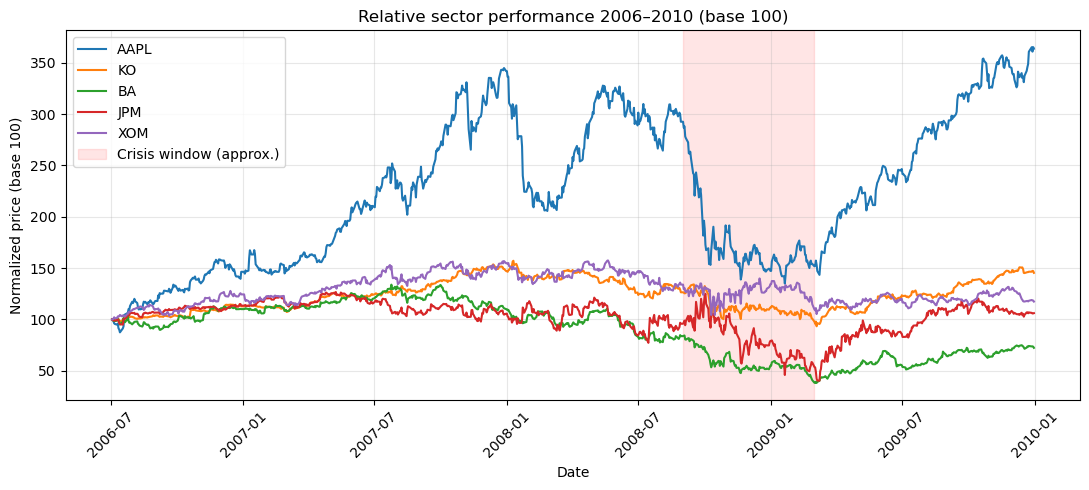

In [18]:
# ── Load prices for the stress period ─────────────────────────────────────
raw_stress = pd.read_csv(CSV_PATH, parse_dates=['date'])
raw_stress = raw_stress[(raw_stress['date'] >= '2006-07-01') &
                        (raw_stress['date'] <= '2010-01-01')]

prices_stress  = raw_stress.pivot_table(
    values='adj_close', index='date', columns='ticker', aggfunc='last').ffill()
returns_stress = prices_stress.pct_change().dropna(how='all')  # only='all' ← correction

print(f'Stress-period returns: {returns_stress.shape}')

# ── Plot ───────────────────────────────────────────────────────────────────
sector_tickers = ['AAPL', 'KO', 'BA', 'JPM', 'XOM',
                  'GE', 'C', 'WMT', 'CVX', 'IBM',
                  'MCD', 'PFE', 'T', 'VZ', 'HD']
available = [t for t in sector_tickers if t in prices_stress.columns][:5]
if not available:
    available = list(prices_stress.columns[:5])

norm_prices = (prices_stress[available] / prices_stress[available].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(11, 5))
for ticker in available:
    ax.plot(norm_prices.index, norm_prices[ticker], label=ticker, linewidth=1.5)
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-03-01'),
           alpha=0.1, color='red', label='Crisis window (approx.)')
ax.set_title('Relative sector performance 2006–2010 (base 100)')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized price (base 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Stress period shape: (912, 150)
Days available after WINDOW_IN=126: 786


GMV backtest: 100%|██████████| 79/79 [00:02<00:00, 34.25it/s]


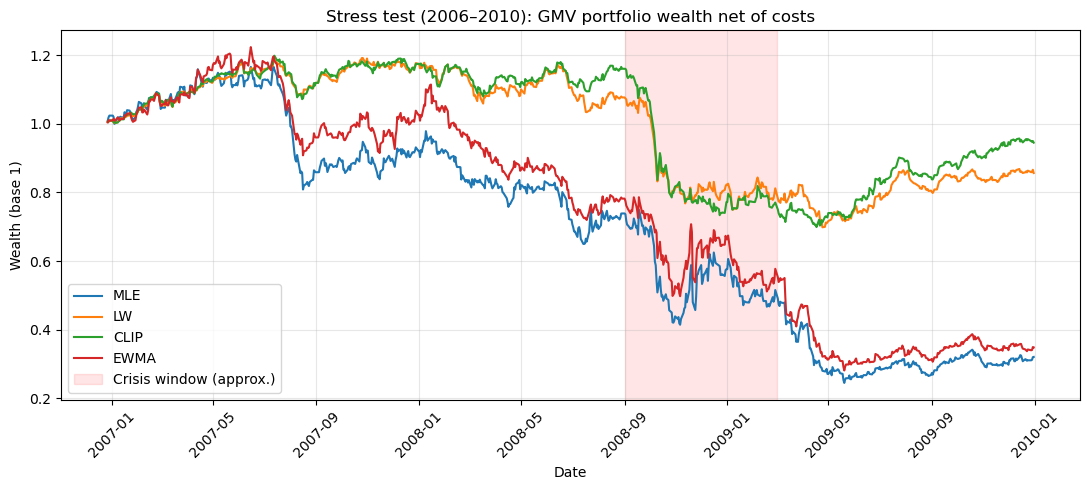

,AnnRet,AnnVol,Sharpe,MaxDD,AvgTO
Strategy,,,,,
CLIP,-0.4%,16.6%,-0.03,-41.7%,0.324
LW,-3.6%,16.2%,-0.23,-41.4%,0.808
MLE,-28.6%,39.4%,-0.73,-79.0%,8.516
EWMA,-27.3%,35.7%,-0.76,-77.0%,7.945


In [19]:
# ── Walk-forward GMV backtest on the stress period ────────────────────────
common_assets = [c for c in data.columns if c in returns_stress.columns]
stress_df     = returns_stress[common_assets].ffill().bfill().dropna(how='any')

print(f"Stress period shape: {stress_df.shape}")
print(f"Days available after WINDOW_IN={WINDOW_IN}: {stress_df.shape[0] - WINDOW_IN}")

if stress_df.shape[0] > WINDOW_IN + REBALANCE_STEP:
    stress_results, stress_summary = backtest_gmv(
        stress_df, COVS,
        window_in=WINDOW_IN,
        rebalance_step=REBALANCE_STEP,
        cost_bps=COST_BPS)

    fig, ax = plt.subplots(figsize=(11, 5))
    for name, d in stress_results.items():
        ax.plot(d['wealth'].index, d['wealth'].values, label=name, linewidth=1.5)
    ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-03-01'),
               alpha=0.1, color='red', label='Crisis window (approx.)')
    ax.set_title('Stress test (2006–2010): GMV portfolio wealth net of costs')
    ax.set_xlabel('Date')
    ax.set_ylabel('Wealth (base 1)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(stress_summary.style.format({'AnnRet': '{:.1%}', 'AnnVol': '{:.1%}',
                                          'Sharpe': '{:.2f}', 'MaxDD': '{:.1%}',
                                          'AvgTO': '{:.3f}'}))
else:
    print(f"Not enough data: {stress_df.shape[0]} days, need {WINDOW_IN + REBALANCE_STEP}.")

### Stress test interpretation (2006–2010)

The stress test covers one of the most severe market dislocations in modern financial history,
including the subprime crisis, the Lehman Brothers collapse (September 2008), and the subsequent
global recession. No long-only GMV strategy escapes the drawdown, but the magnitude of losses
differs dramatically across covariance estimators.

**CLIP and LW prove remarkably resilient.** Both limit annualized losses to near zero (-0.4% and
-3.6% respectively) with a maximum drawdown around -41%, and crucially, they recover most of
their losses by early 2010. Their low turnover (0.32 and 0.81) confirms that filtered covariance
matrices remain stable under stress: even as correlations spike across the board, eigenvalue
cleaning and shrinkage prevent the optimizer from generating wild rebalancing signals.

**MLE and EWMA collapse.** MLE suffers a -79% maximum drawdown and annualized losses of -28.6%,
while EWMA is similarly devastated (-77%, -27.3%). Both strategies exhibit extreme turnover
(~8x per rebalance), meaning transaction costs compound an already catastrophic situation.
The mechanism is clear: when correlations converge toward 1 during a crisis, the raw sample
covariance becomes nearly singular, covariance inversion amplifies noise into extreme weights,
and the portfolio churns destructively.

**The key takeaway** is that covariance regularization is not only a performance enhancer in
normal times — it is a risk management tool in tail events. The gap between filtered and
unfiltered estimators widens precisely when it matters most.

## Conclusion

This project investigated portfolio construction along two complementary axes, combining the
first and second modules of the course.

**From Module 1 (Optimization):**
- GMV portfolios are highly sensitive to covariance noise. Without regularization, frequent
  rebalancing combined with transaction costs quickly erodes performance: GMV-MLE and GMV-EWMA
  reach drawdowns of -53% and -42% respectively, with turnover above 6x per rebalance.
- Robust Optimization provides a principled hedge against estimation uncertainty, but its
  marginal benefit vanishes once the covariance is already well-regularized. RO variants
  achieve Sharpe ratios of 1.53–1.98, well below the 3.01 of GMV-CLIP and GMV-LW.

**From Module 2 (Covariance Cleaning):**
- Marchenko–Pastur theory confirms that 86% of empirical eigenvalues are noise-driven on this
  dataset (q = 0.15). This directly motivates eigenvalue cleaning before any optimization.
- Ledoit–Wolf shrinkage and RMT eigenvalue clipping both achieve Sharpe ratios of 3.01,
  stabilize GMV weights, and keep turnover below 0.27. They dominate all other approaches.
- The neural network learns covariance cleaning end-to-end via a biLSTM eigenvalue filter.
  Under limited training data (~1000 days), it converges toward a near-1/N allocation
  (SR=1.43, MaxDD=-5.1%, TO=0.075) — a conservative but implementable strategy.

**Overall ranking (net of costs, full sample):**
GMV-CLIP ≈ GMV-LW > RO variants > NN-GMV > GMV-EWMA > GMV-MLE

**Stress test (2006–2010):** the ranking holds under crisis conditions. CLIP and LW limit
annualized losses to near zero with drawdowns around -41%, while MLE and EWMA collapse
(-53% and -42% drawdown) due to covariance instability under correlated market stress.

The dominant lesson is that **getting the covariance right is more valuable than optimizing
the objective function**. A simple analytical GMV portfolio combined with a well-designed
covariance cleaning method outperforms more complex optimization schemes in every dimension
that matters: Sharpe ratio, maximum drawdown, turnover, and crisis resilience.